                            OLS Regression Results                            
Dep. Variable:           unemployment   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     12.03
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           0.000729
Time:                        13:51:15   Log-Likelihood:                -161.14
No. Observations:                 121   AIC:                             326.3
Df Residuals:                     119   BIC:                             331.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.7638      0.096     49.677      0.0

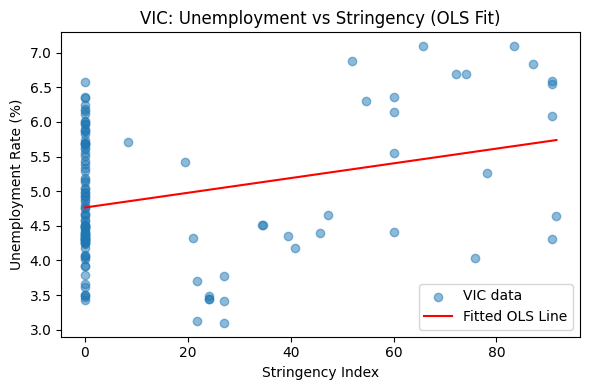

In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import matplotlib.pyplot as plt

df = pd.read_csv('../data/clean/merged_stringency_unemployment.csv')

df = df.rename(columns={
    'VIC_Unemployment': 'VIC_unemployment',
    'NSW_Unemployment': 'NSW_unemployment',
    'VIC_Stringency': 'VIC_stringency',
    'NSW_Stringency': 'NSW_stringency'
})

df['Date'] = pd.to_datetime(df['Date'])

vic = df[['Date', 'VIC_unemployment', 'VIC_stringency']].copy()
vic['state'] = 'VIC'
vic = vic.rename(columns={
    'VIC_unemployment': 'unemployment',
    'VIC_stringency': 'stringency'
})

nsw = df[['Date', 'NSW_unemployment', 'NSW_stringency']].copy()
nsw['state'] = 'NSW'
nsw = nsw.rename(columns={
    'NSW_unemployment': 'unemployment',
    'NSW_stringency': 'stringency'
})

panel = pd.concat([vic, nsw], ignore_index=True)
panel['NSW'] = (panel['state'] == 'NSW').astype(int)

vic_data = panel[panel['state'] == 'VIC']
nsw_data = panel[panel['state'] == 'NSW']

model_vic = smf.ols('unemployment ~ stringency', data=vic_data).fit()
model_nsw = smf.ols('unemployment ~ stringency', data=nsw_data).fit()
model_pooled = smf.ols('unemployment ~ stringency * NSW', data=panel).fit()

print(model_vic.summary())
print(model_nsw.summary())
print(model_pooled.summary())

results = {
    'VIC only': model_vic,
    'NSW only': model_nsw,
    'Pooled (interaction)': model_pooled
}

table = summary_col(
    list(results.values()),
    model_names=list(results.keys()),
    stars=True,
    info_dict={
        'N': lambda x: f"{int(x.nobs)}",
        'R-squared': lambda x: f"{x.rsquared:.3f}"
    }
)

print(table)

with open('../outputs/regression_table.txt', 'w') as f:
    f.write(table.as_text())

plt.figure(figsize=(6,4))
plt.scatter(vic_data['stringency'], vic_data['unemployment'], alpha=0.5, label='VIC data')
x_vals = np.linspace(vic_data['stringency'].min(), vic_data['stringency'].max(), 100)
y_vals = model_vic.params['Intercept'] + model_vic.params['stringency'] * x_vals
plt.plot(x_vals, y_vals, color='red', label='Fitted OLS Line')
plt.xlabel('Stringency Index')
plt.ylabel('Unemployment Rate (%)')
plt.title('VIC: Unemployment vs Stringency (OLS Fit)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/vic_fit.png', dpi=300)
plt.show()
